In [65]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
import scipy as sp
from scipy.stats import beta, chi2
import emcee 
import corner as cp
import sbi
from sbi.inference import NPE
from sbi import analysis as analysis
from sbi import utils as utils
from sbi.utils.user_input_checks import (
    check_sbi_inputs,
    process_prior,
    process_simulator,
)
import math
import os
import torch
import csv
from sbi.analysis import pairplot
import pandas as pd


Dataset 1 Analysis

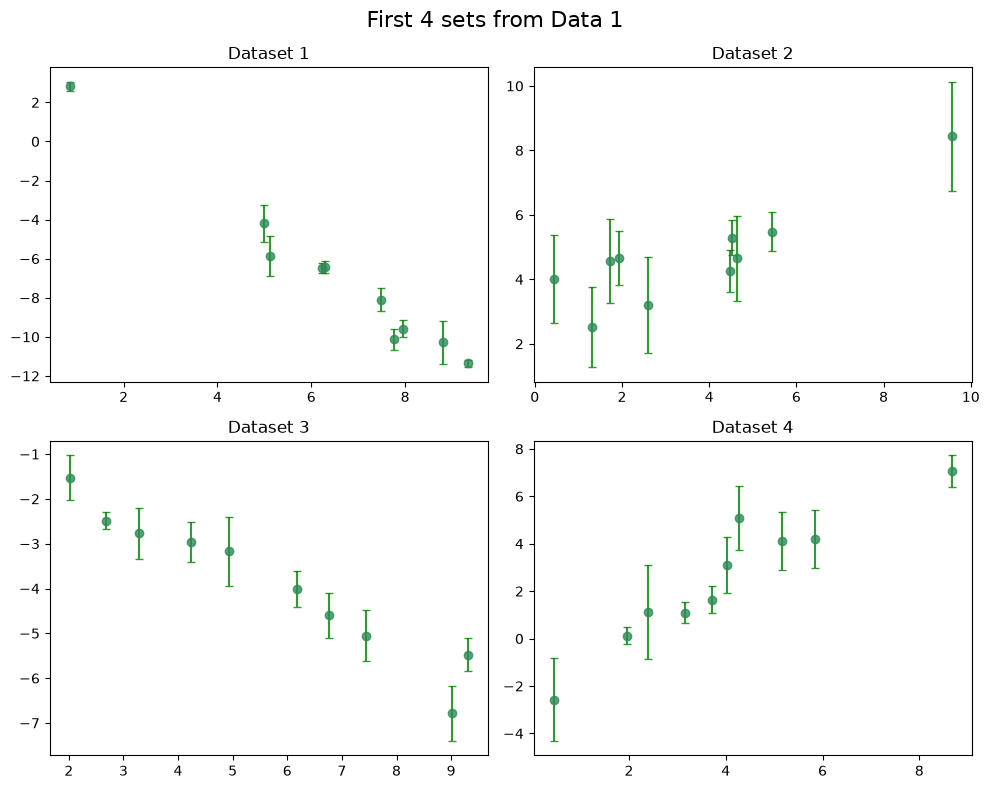

In [66]:
df = pd.read_csv('data1.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='seagreen',
                ecolor='green', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 1', fontsize=16)    
plt.tight_layout()
plt.show()


a = -1.6626831831611895, b = 3.817560809159585
a = 0.5117862550776586, b = 2.831272857074634
a ranges from -2.014 to 2.173
b ranges from -5.394 to 5.513


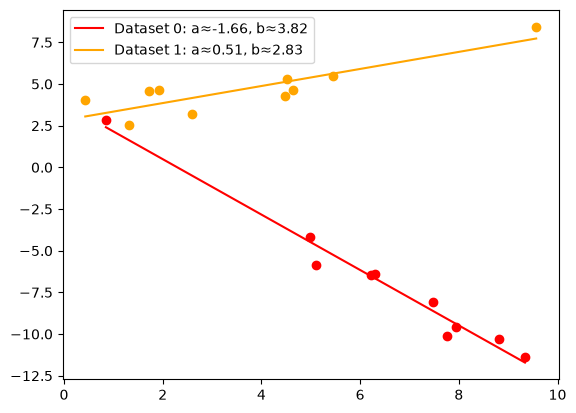

In [24]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')

In [67]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_1 = BoxUniform(low=torch.tensor([-4., -7.]), 
                      high=torch.tensor([4., 7.]))

prior_samples1 = prior_1.sample((10000,))


In [68]:
#Assuming linear model
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_1.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_1)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)



 Neural network successfully converged after 205 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -1.715865 0.045888  4.303990 0.306396
       1  0.450637 0.151956  3.045806 0.734308
       2 -0.570521 0.056011 -0.749787 0.322097
       3  1.066684 0.102889 -1.907573 0.482952
       4  1.060423 0.088490  2.701342 0.325622
       5  1.867662 0.111626  1.719035 0.384706
       6 -1.569175 0.029668 -1.191711 0.138184
       7 -1.268830 0.125718  3.368722 0.625979
       8  1.455191 0.137920 -4.302876 0.811628
       9  0.532099 0.089556 -3.249694 0.438269
      10 -1.595355 0.080776  4.625956 0.395281
      11  0.086545 0.068923 -4.072337 0.318788
      12 -0.821971 0.227824  2.012316 0.872241
      13  0.079056 0.177115  3.515890 0.659006
      14  0.041257 0.034719  2.521514 0.168297
      15 -1.040283 0.059042 -4.111219 0.340215
      16  0.163585 0.115179 -3.703566 0.837364
      17  0.321763 0.130296 -0.564089 0.354251
      18 -0.807857 0.080654  2.335629 0.570365
      19 -0.923517 0.156629  0.128340 1.107491
      20  1.6

  0%|          | 0/5000 [00:00<?, ?it/s]

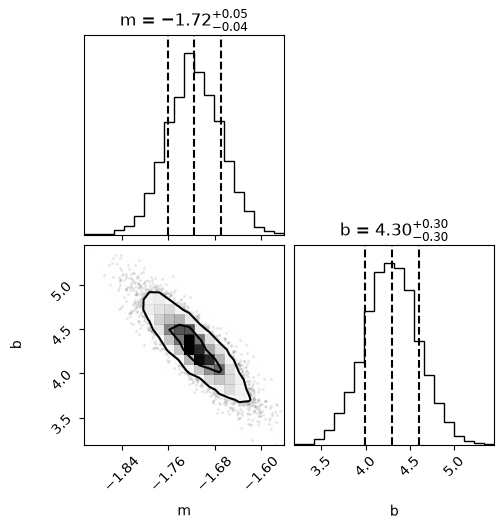

In [69]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)



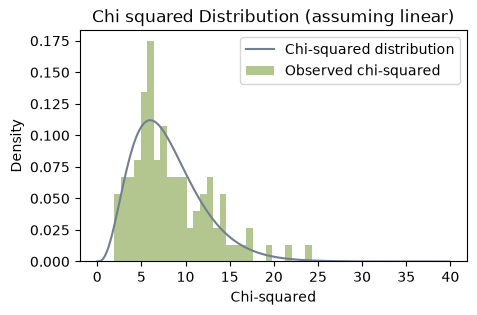

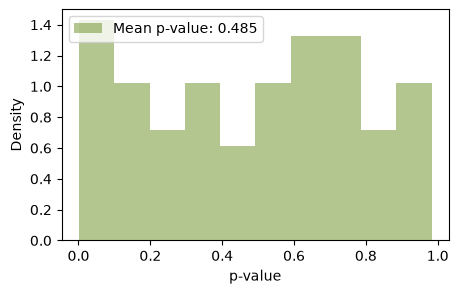

In [70]:
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean']

    y_sbi = a * d['x'] + b  
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_sbi) / sigma_obs) ** 2)
    chi2s.append(chi2)

chi2_dist = sp.stats.chi2(df=len(y_obs)-2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.legend()
plt.title('Chi squared Distribution (assuming linear)')
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()


/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has extreme outliers in dimension(s) [1] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 249 epochs. dataset    a_mean    a_std    b_mean    b_std    c_mean    c_std
       0 -0.015863 0.047579 -1.512798 0.467771  3.687884 0.656653
       1  0.053174 0.069191  0.108482 0.659458  3.123136 1.252428
       2  0.006127 0.053830 -0.632296 0.611971 -0.609040 1.392348
       3 -0.050061 0.073088  1.625265 0.719256 -2.736668 1.441750
       4  0.000210 0.090941  1.016510 0.884704  2.937072 1.314180
       5  0.045384 0.088287  1.672864 0.667090  1.905633 0.927846
       6  0.006766 0.040824 -1.658369 0.336212 -1.068574 0.252322
       7  0.020900 0.071624 -1.468668 0.721740  3.779312 1.479443
       8  0.091137 0.102755  0.352494 1.149007 -1.755769 2.657276
       9  0.019866 0.053267  0.358042 0.532705 -3.105992 0.854296
      10  0.009178 0.047348 -1.676259 0.460582  4.621908 0.725042
      11  0.085466 0.044422 -0.602765 0.387880 -3.981345 0.416285
      12  0.033469 0.082380 -0.921454 0.733240  1.845678 1.387234
      13  0.029575 0

  0%|          | 0/5000 [00:00<?, ?it/s]

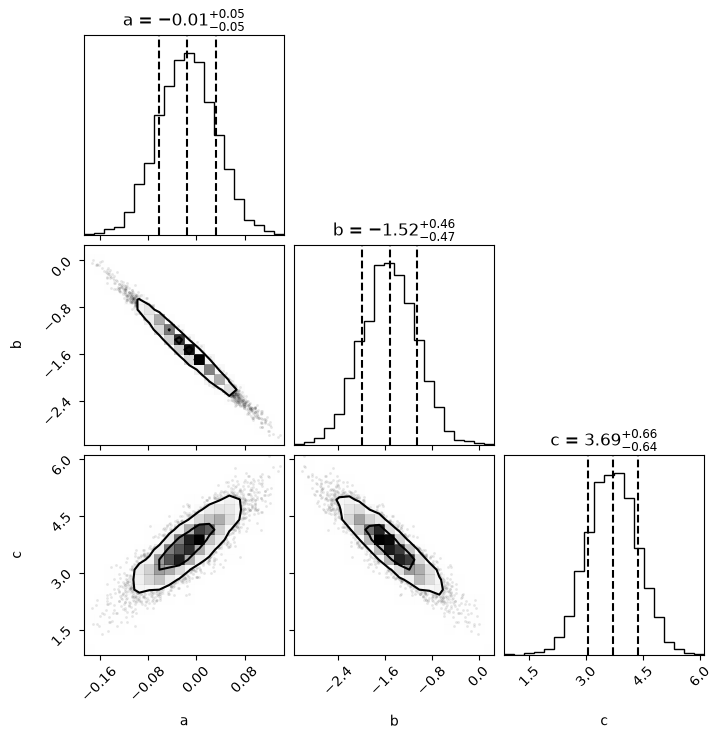

In [71]:
#Quadratic version
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_1 = BoxUniform(low=torch.tensor([-4., -7., -7.]), 
                      high=torch.tensor([4., 7., 7.]))

prior_samples1 = prior_1.sample((10000,))
n_points = 10  

def quad_simulator(theta, x, sigma):
    coef_a, coef_b, coef_c = theta[0].item(), theta[1].item(), theta[2].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x**2 + coef_b * x + coef_c + sim_noise
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_1.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(quad_simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_1)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

#List of a, b, c found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
        'c_mean': posterior_mean[2].item(),
        'c_std': posterior_std[2].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["a", "b", "c"]
fig = cp.corner(flat_samples[:, :3], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)

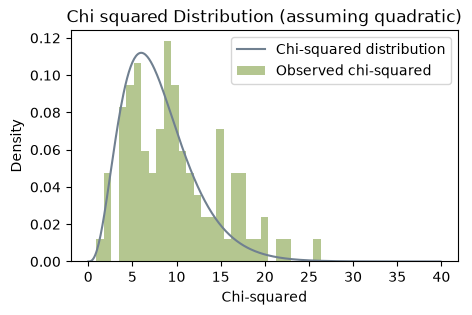

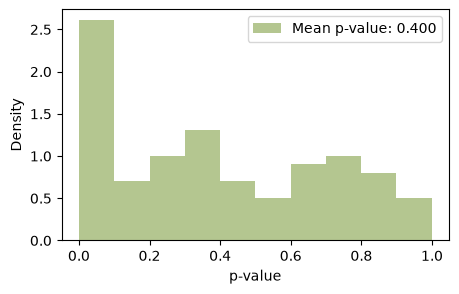

In [72]:
#Quadratic version
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b, c = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean'], results_list[ds_id]['c_mean']
    y_fit = a * d['x']**2 + b * d['x'] + c
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_fit) / sigma_obs) ** 2)
    chi2s.append(chi2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.title('Chi squared Distribution (assuming quadratic)')
plt.legend()
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p_1 = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p_1:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [32]:
#How good is this fitting? Doing a sort of posterior predictive check
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)



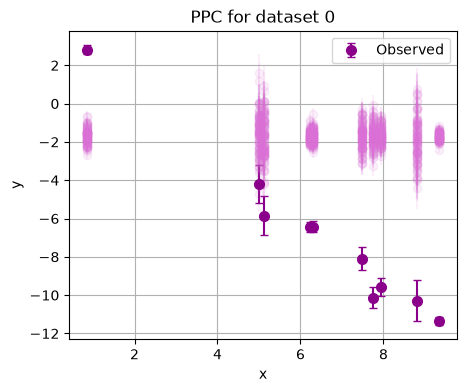

In [33]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100): ax.errorbar(x_obs, y_rep[i], yerr=sigma_obs, fmt='o',  color='orchid', alpha=0.1)

ax.errorbar(x_obs, y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed')

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id}')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:1.0


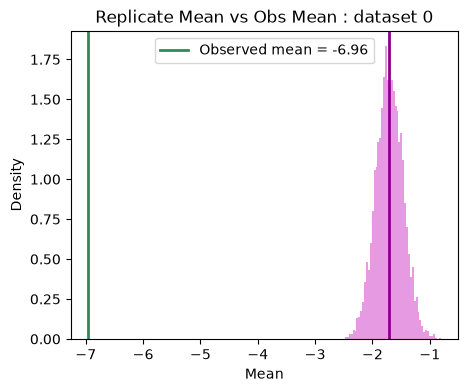

$\Delta$ mean = 5.25


In [34]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean, bins=50, density=True, color='orchid', alpha=0.7)

ax.axvline(T_rep_mean_mean, color='darkmagenta', linewidth=2,)
ax.axvline(T_obs_mean, color='seagreen', linewidth=2, label=f'Observed mean = {T_obs_mean:.2f}')

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id}')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


In [35]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std, bins=50, density=True, color='orchid',alpha=0.7)
ax.axvline(T_rep_std_mean,color='darkmagenta',linewidth=2,)

ax.axvline(T_obs_std,color='seagreen',linewidth=2, label=f'Observed std = {T_obs_std:.2f})

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id}')
ax.legend()

plt.show()


SyntaxError: unterminated string literal (detected at line 14) (2211164476.py, line 14)

Dataset 2 Analysis

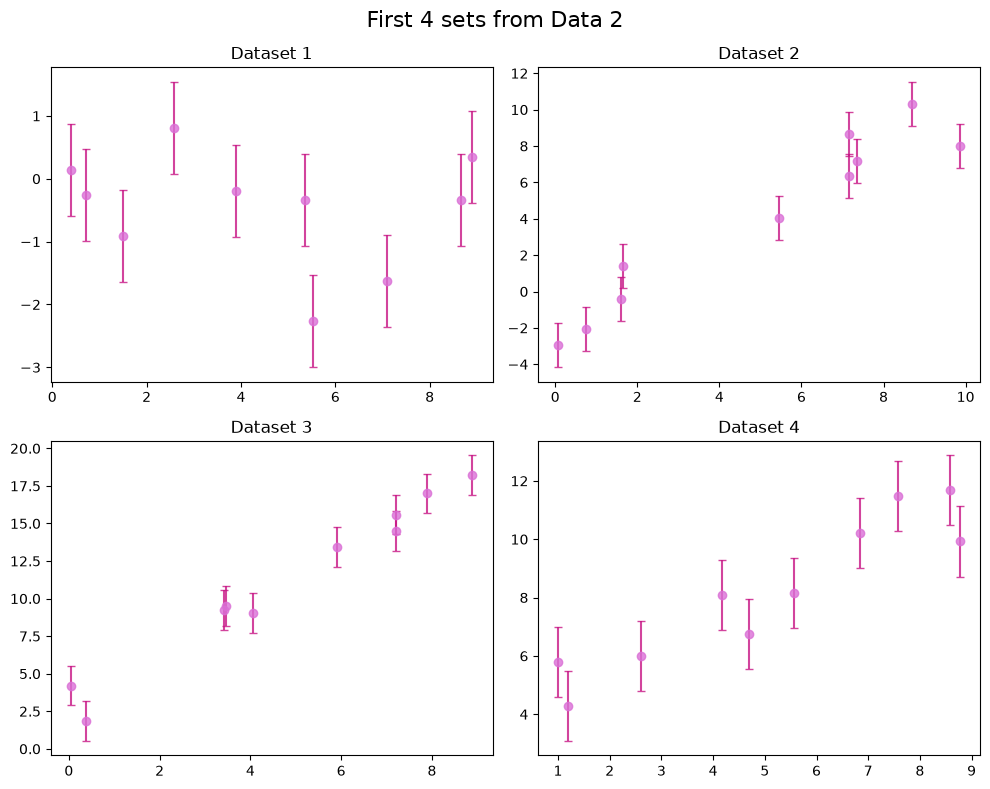

In [73]:
df = pd.read_csv('data2.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='orchid',
                ecolor='mediumvioletred', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 2', fontsize=16)    
plt.tight_layout()
plt.show()

a = -0.05870621822704653, b = -0.20185870388723284
a = 1.2724290503034936, b = -2.272903504453701
a ranges from -2.048 to 2.025
b ranges from -5.716 to 6.051


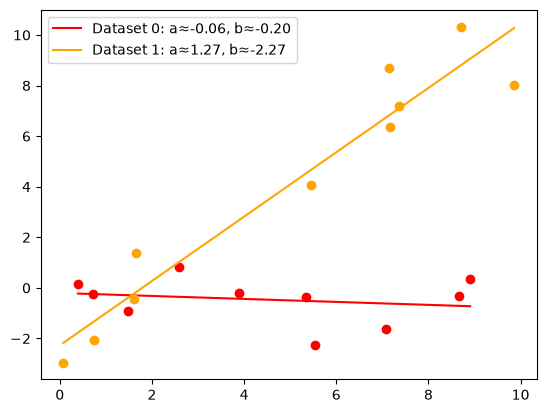

In [ ]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')

In [74]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_2 = BoxUniform(low=torch.tensor([-3, -8]), 
                      high=torch.tensor([3, 8]))

prior_samples2 = prior_2.sample((10000,))

In [75]:
#Assuming linear model
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_2.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_2)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 76 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -0.058662 0.072592 -0.251829 0.409124
       1  1.290381 0.115774 -2.308122 0.686265
       2  1.739991 0.148796  2.867110 0.823438
       3  0.800201 0.133931  4.150941 0.770985
       4 -0.642461 0.165955 -0.879932 0.886446
       5  0.669901 0.095423  4.001590 0.481767
       6  1.026443 0.060440 -2.312652 0.380484
       7  1.314915 0.082900 -3.719646 0.578722
       8  0.264071 0.076373  0.035024 0.381599
       9  1.407662 0.217881 -4.963105 1.129643
      10  1.154631 0.140422 -1.160087 0.786132
      11  1.152871 0.164063 -0.923399 1.332802
      12 -0.121286 0.173658 -5.258439 1.184201
      13  1.775998 0.064485  1.274723 0.358214
      14  1.278214 0.162254 -2.818372 0.812925
      15 -1.222491 0.037175 -2.960848 0.203327
      16 -1.245182 0.088264  1.213795 0.502931
      17 -0.513188 0.154607 -1.900743 0.576165
      18  0.279721 0.127108  5.958996 0.794569
      19  0.598182 0.150456  0.890095 0.749373
      20  1.8

  0%|          | 0/5000 [00:00<?, ?it/s]

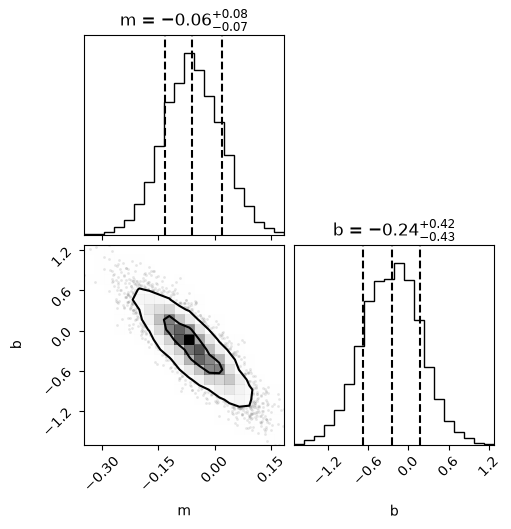

In [39]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)



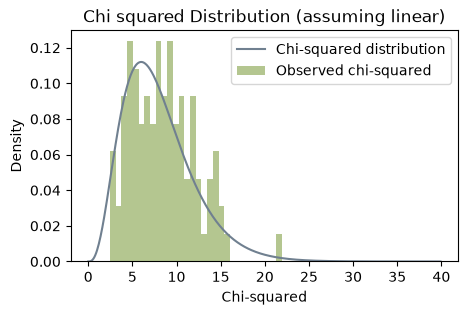

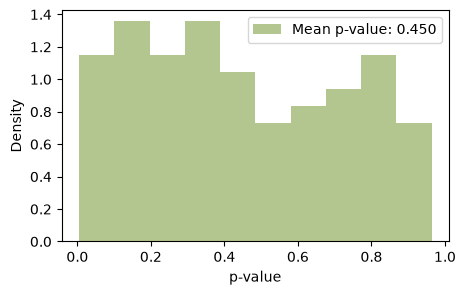

In [40]:
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean']

    y_sbi = a * d['x'] + b  
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_sbi) / sigma_obs) ** 2)
    chi2s.append(chi2)

chi2_dist = sp.stats.chi2(df=len(y_obs)-2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.legend()
plt.title('Chi squared Distribution (assuming linear)')
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has extreme outliers in dimension(s) [0] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 157 epochs. dataset    a_mean    a_std    b_mean    b_std    c_mean    c_std
       0  0.029612 0.042190 -0.291561 0.379307  0.015621 0.595890
       1 -0.081852 0.054069  2.034243 0.523410 -2.959389 0.829840
       2  0.000992 0.062030  1.777570 0.563087  2.616868 0.962984
       3 -0.028443 0.058878  1.131018 0.563000  3.360768 0.995697
       4  0.008832 0.091640 -0.715260 0.870464 -0.728459 1.493421
       5  0.003283 0.033877  0.666862 0.308079  3.890183 0.578474
       6  0.002897 0.040747  0.955661 0.467427 -2.187005 1.145059
       7  0.049388 0.051429  0.615120 0.634475 -1.888803 1.723403
       8  0.082853 0.046673 -0.361436 0.348430  0.879084 0.499256
       9  0.181521 0.098029 -0.326871 0.858919 -1.509177 1.806596
      10 -0.058790 0.098179  1.677024 0.811221 -1.883088 1.175312
      11 -0.000033 0.066475  1.064535 0.790249 -0.766765 2.120086
      12  0.055346 0.055762 -0.752236 0.500597 -3.776115 0.908547
      13 -0.010260 0

  0%|          | 0/5000 [00:00<?, ?it/s]

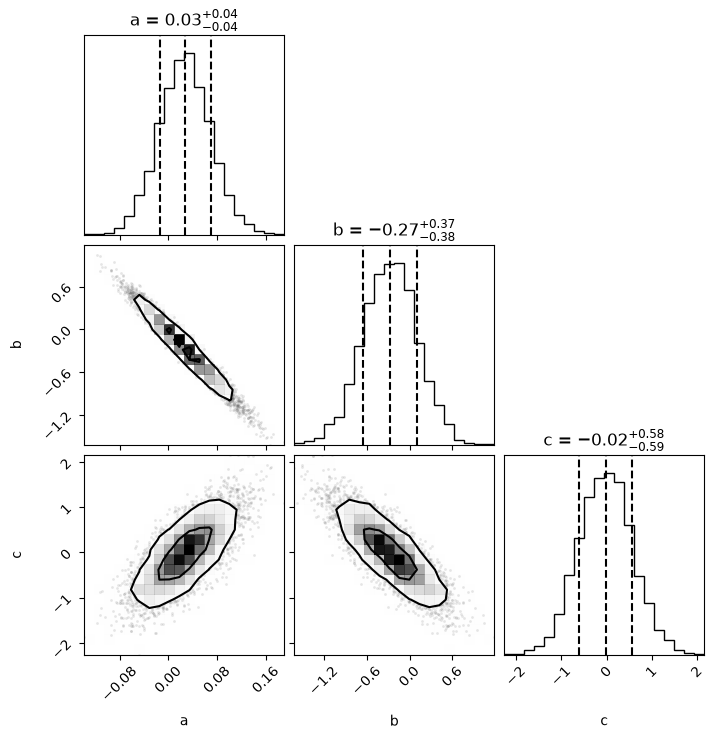

In [ ]:
#Quadratic version

prior_2 = BoxUniform(low=torch.tensor([-3, -8, -7]), 
                      high=torch.tensor([3, 8, 7]))

prior_samples2 = prior_2.sample((10000,)) 

n_points = 10  

def quad_simulator(theta, x, sigma):
    coef_a, coef_b, coef_c = theta[0].item(), theta[1].item(), theta[2].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x**2 + coef_b * x + coef_c + sim_noise
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_2.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(quad_simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_2)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

#List of a, b, c found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
        'c_mean': posterior_mean[2].item(),
        'c_std': posterior_std[2].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["a", "b", "c"]
fig = cp.corner(flat_samples[:, :3], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)


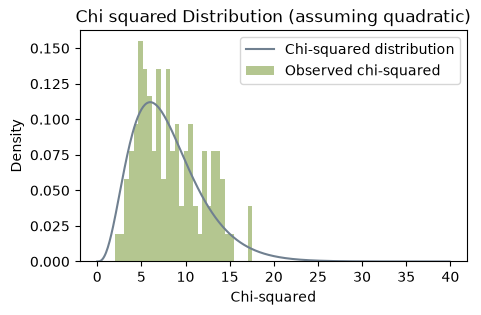

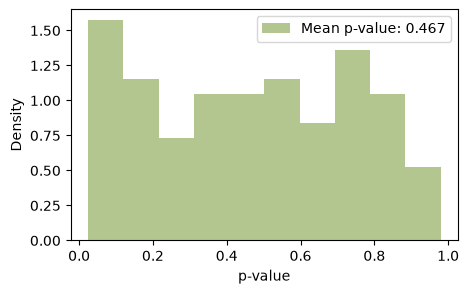

In [42]:
#Quadratic version
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b, c = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean'], results_list[ds_id]['c_mean']
    y_fit = a * d['x']**2 + b * d['x'] + c
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_fit) / sigma_obs) ** 2)
    chi2s.append(chi2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.title('Chi squared Distribution (assuming quadratic)')
plt.legend()
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p_2 = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p_2:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
#posterior predictive check for data2
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)


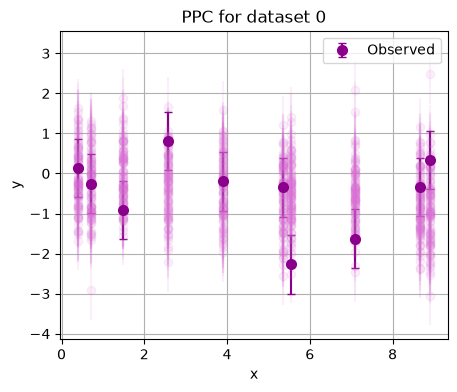

In [ ]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100):
    ax.errorbar(x_obs,
        y_rep[i],
        yerr=sigma_obs,
        fmt='o',
        color='orchid',
        alpha=0.1
    )

ax.errorbar(x_obs,
    y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id}')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:0.5806


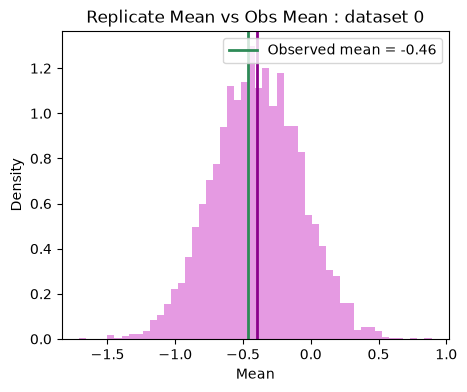

$\Delta$ mean = 0.07


In [ ]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)

ax.axvline(T_rep_mean_mean,
    color='darkmagenta',
    linewidth=2,
)
ax.axvline(T_obs_mean,
    color='seagreen',
    linewidth=2,
    label=f'Observed mean = {T_obs_mean:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id}')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


p_B for standard deviation: 0.2546


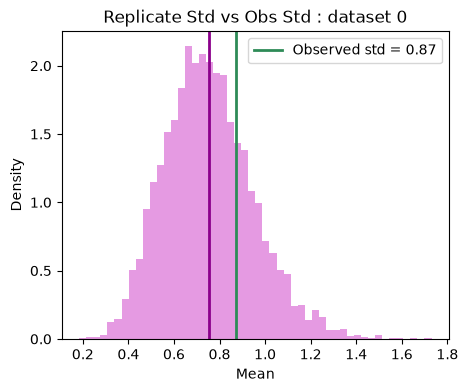

In [ ]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)
ax.axvline(T_rep_std_mean,
    color='darkmagenta',
    linewidth=2,
)

ax.axvline(T_obs_std,
    color='seagreen',
    linewidth=2,
    label=f'Observed std = {T_obs_std:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id}')
ax.legend()

plt.show()


Dataset 3 Analysis

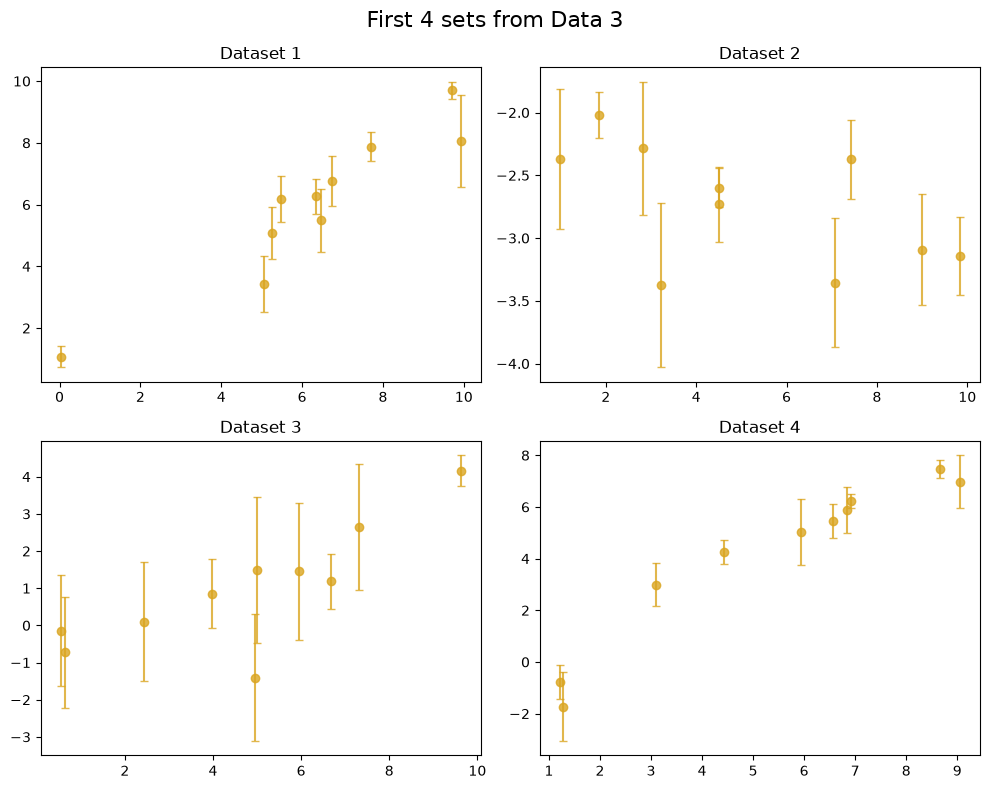

In [43]:
df = pd.read_csv('data3.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='goldenrod',
                ecolor='goldenrod', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 3', fontsize=16)    
plt.tight_layout()
plt.show()

a = 0.831741863756199, b = 0.7786789187407074
a = -0.08873758170742081, b = -2.279883113347441
a ranges from -3.067 to 2.161
b ranges from -7.046 to 7.129


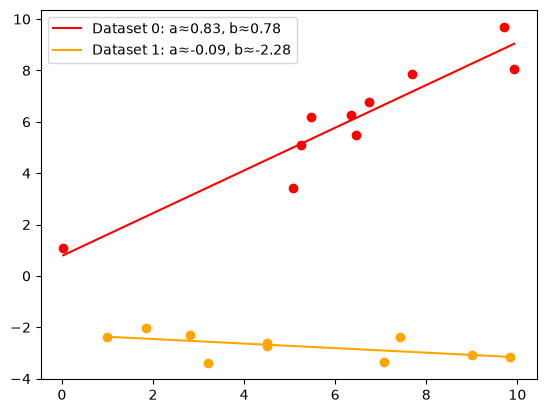

In [ ]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit, label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')


In [44]:
#Creating a prior for the set based on that range

prior_3 = BoxUniform(low=torch.tensor([-3, -7]), 
                      high=torch.tensor([4, 7]))

prior_samples3 = prior_3.sample((10000,))

In [45]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise
    
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_3.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_3)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 262 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -0.059018 0.076217 -0.196053 0.422895
       1  1.281159 0.123947 -2.256306 0.700071
       2  1.707454 0.152342  2.950125 0.838728
       3  0.812800 0.133611  4.141875 0.786158
       4 -0.633865 0.160352 -0.870319 0.892254
       5  0.671590 0.099431  4.027165 0.494574
       6  1.040858 0.063896 -2.348700 0.394221
       7  1.312589 0.087736 -3.711797 0.624714
       8  0.255726 0.083233  0.110630 0.411668
       9  1.435992 0.238246 -5.168468 1.192035
      10  1.159879 0.145891 -1.125605 0.823428
      11  1.141178 0.173497 -0.835145 1.345072
      12 -0.099998 0.174790 -5.375865 1.153028
      13  1.763903 0.070572  1.331400 0.389884
      14  1.260867 0.160691 -2.846832 0.793535
      15 -1.231305 0.040377 -2.846667 0.220703
      16 -1.234159 0.092450  1.247003 0.528632
      17 -0.519080 0.146486 -1.886639 0.548654
      18  0.303038 0.130751  5.841813 0.798286
      19  0.586952 0.139922  0.982518 0.666255
      20  1.8

  0%|          | 0/5000 [00:00<?, ?it/s]

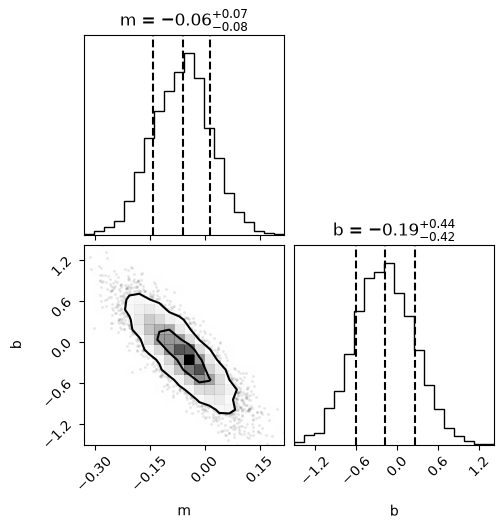

In [76]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["m", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)

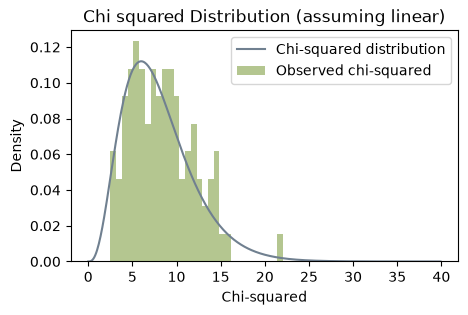

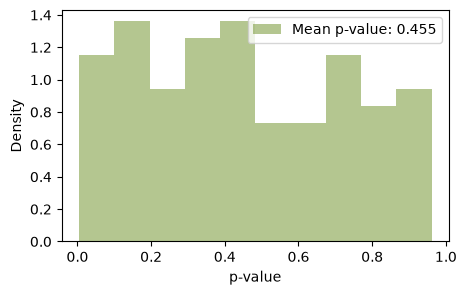

In [77]:
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean']

    y_sbi = a * d['x'] + b  
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_sbi) / sigma_obs) ** 2)
    chi2s.append(chi2)

chi2_dist = sp.stats.chi2(df=len(y_obs)-2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.legend()
plt.title('Chi squared Distribution (assuming linear)')
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

 Neural network successfully converged after 231 epochs. dataset    a_mean    a_std    b_mean    b_std    c_mean    c_std
       0  0.028272 0.037995 -0.311835 0.355646  0.181496 0.593947
       1 -0.073682 0.055822  2.002332 0.555809 -3.138753 0.861576
       2  0.019920 0.060125  1.589985 0.536483  2.948555 0.966762
       3  0.004311 0.062892  0.827172 0.619887  3.910470 1.242964
       4 -0.002590 0.093059 -0.530556 0.880882 -1.263011 1.545807
       5  0.016851 0.038257  0.516380 0.358655  4.208801 0.705480
       6 -0.021004 0.038583  1.247609 0.458428 -2.909159 1.143581
       7  0.024242 0.055182  0.971693 0.692744 -2.872032 1.882929
       8  0.094231 0.039347 -0.500736 0.316032  1.001674 0.538675
       9  0.203675 0.101510 -0.332914 0.915728 -2.166305 1.969094
      10 -0.022025 0.100619  1.393992 0.862057 -1.926443 1.362920
      11  0.045725 0.074401  0.571911 0.944210  0.347543 2.779856
      12  0.057178 0.064412 -0.669850 0.611103 -4.664574 1.252495
      13  0.011157 0

  0%|          | 0/5000 [00:00<?, ?it/s]

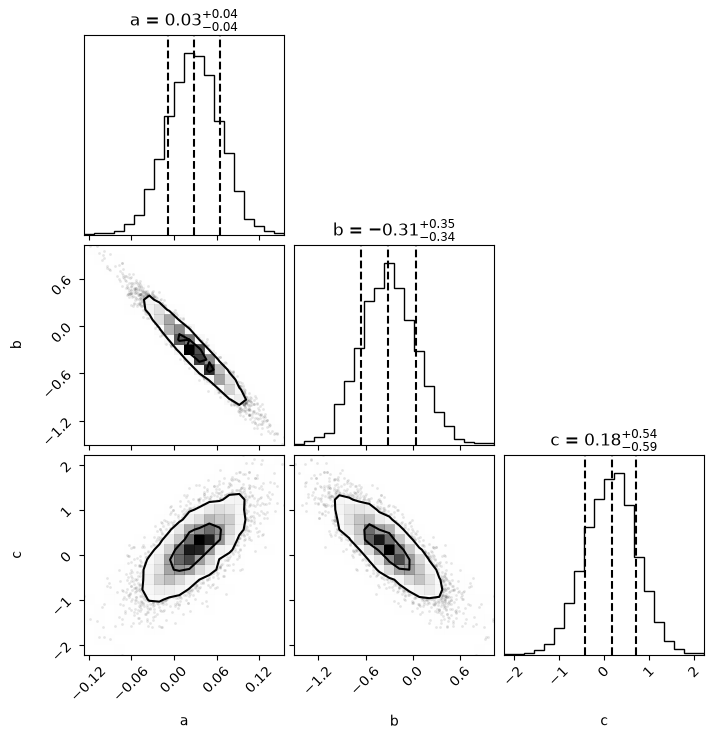

In [78]:
#Quadratic version
prior_3 = BoxUniform(low=torch.tensor([-3., -7., -7.]), 
                      high=torch.tensor([4., 7., 7.]))

prior_samples3 = prior_3.sample((10000,)) 

n_points = 10  

def quad_simulator(theta, x, sigma):
    coef_a, coef_b, coef_c = theta[0].item(), theta[1].item(), theta[2].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x**2 + coef_b * x + coef_c + sim_noise
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_3.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(quad_simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_3)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

#List of a, b, c found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
        'c_mean': posterior_mean[2].item(),
        'c_std': posterior_std[2].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["a", "b", "c"]
fig = cp.corner(flat_samples[:, :3], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)


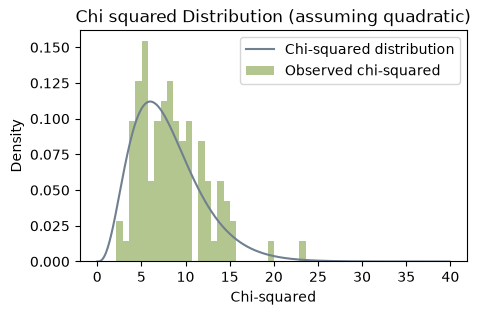

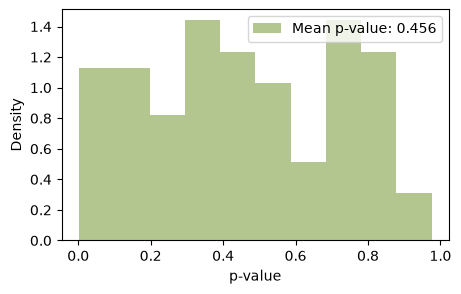

In [79]:
#Quadratic version
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b, c = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean'], results_list[ds_id]['c_mean']
    y_fit = a * d['x']**2 + b * d['x'] + c
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_fit) / sigma_obs) ** 2)
    chi2s.append(chi2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.title('Chi squared Distribution (assuming quadratic)')
plt.legend()
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p_3 = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p_3:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [ ]:
#data 3
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)


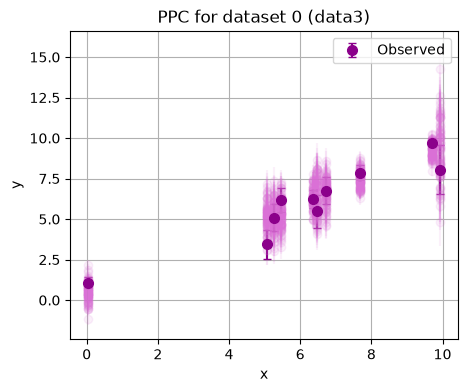

In [ ]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100):
    ax.errorbar(x_obs,
        y_rep[i],
        yerr=sigma_obs,
        fmt='o',
        color='orchid',
        alpha=0.1
    )

ax.errorbar(x_obs,
    y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id} (data3)')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:0.7268


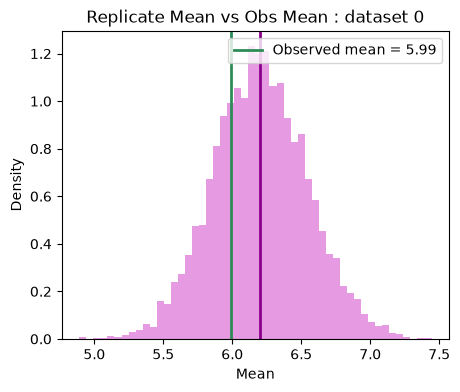

$\Delta$ mean = 0.21


In [ ]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)

ax.axvline(T_rep_mean_mean,
    color='darkmagenta',
    linewidth=2,
)
ax.axvline(T_obs_mean,
    color='seagreen',
    linewidth=2,
    label=f'Observed mean = {T_obs_mean:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id}')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


p_B for standard deviation: 0.717


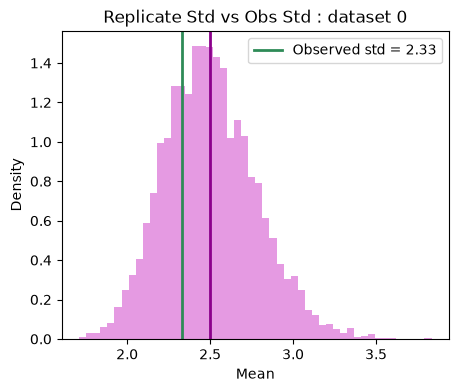

In [ ]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)
ax.axvline(T_rep_std_mean,
    color='darkmagenta',
    linewidth=2,
)

ax.axvline(T_obs_std,
    color='seagreen',
    linewidth=2,
    label=f'Observed std = {T_obs_std:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id}')
ax.legend()

plt.show()


Dataset 4 Analysis

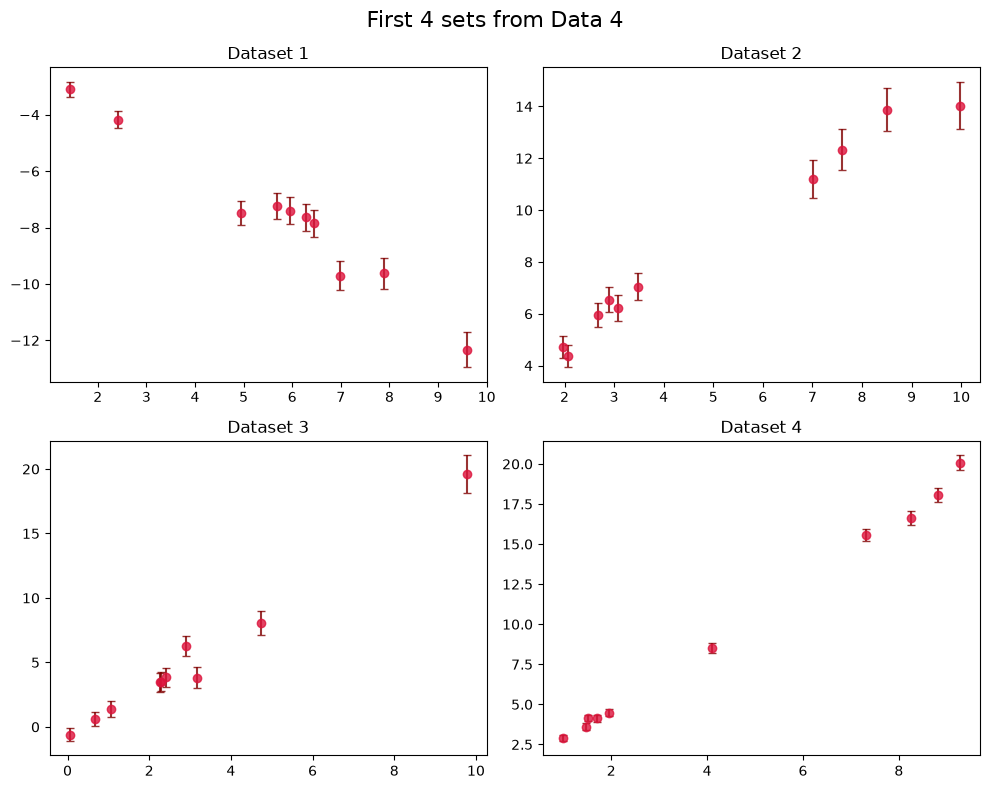

In [80]:
df = pd.read_csv('data4.csv')
datasets = list(df.groupby('dataset'))   

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
for ax, (ds_id, d) in zip(axes.flat, datasets[:4]):
    ax.errorbar(d['x'], d['y'], yerr=d['sigma'], fmt='o', color='crimson',
                ecolor='maroon', capsize=3, alpha=0.8)
    ax.set_title(f'Dataset {ds_id+1}')
plt.suptitle('First 4 sets from Data 4', fontsize=16)    
plt.tight_layout()
plt.show()

a = -1.0785345154908206, b = -1.436439410083085
a = 1.2538404780466545, b = 2.4520852111998557
a ranges from -2.127 to 2.190
b ranges from -4.904 to 5.678


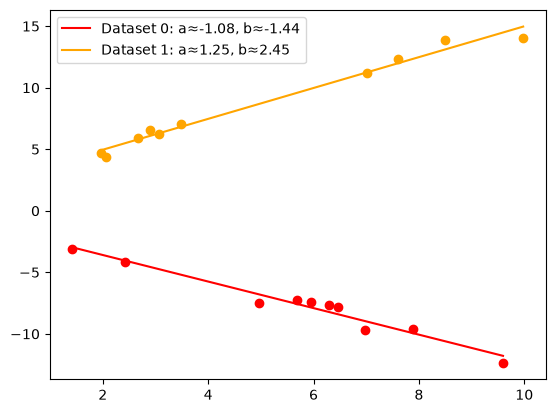

In [ ]:
#getting an idea of the range of slopes
a_fits = []
b_fits = []
#c_fits = []

for ds_id, d in list(datasets)[:]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)

    a_fits.append(a_fit)
    b_fits.append(b_fit)
    #c_fits.append(c_fit)

color = ['red', 'orange']
for ds_id, d in list(datasets)[:2]:
    a_fit, b_fit = np.polyfit(d['x'], d['y'], 1)
    plt.plot(d['x'], a_fit * d['x'] + b_fit  , label=f'Dataset {ds_id}: a≈{a_fit:.2f}, b≈{b_fit:.2f}', color = color[ds_id])
    plt.plot(d['x'], d['y'], 'o', color = color[ds_id])
    plt.legend()
    print(f'a = {a_fit}, b = {b_fit}')


print(f'a ranges from {min(a_fits):.3f} to {max(a_fits):.3f}')
print(f'b ranges from {min(b_fits):.3f} to {max(b_fits):.3f}')
#print(f'c ranges from {min(c_fits):.3f} to {max(c_fits):.3f}')

In [81]:
#Creating a prior for the set based on that range
from sbi.utils import BoxUniform

prior_4 = BoxUniform(low=torch.tensor([-6., -6.]), 
                      high=torch.tensor([3., 6.]))

prior_samples4 = prior_4.sample((10000,))


In [82]:
n_points = 10  

def simulator(theta, x, sigma):
    coef_a, coef_b = theta[0].item(), theta[1].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x + coef_b + sim_noise

    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000  
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_4.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_4)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

 Neural network successfully converged after 120 epochs.

 dataset    a_mean    a_std    b_mean    b_std
       0 -1.061992 0.057378 -1.539468 0.281974
       1  1.336594 0.086260  2.064618 0.370881
       2  1.989055 0.125472 -0.788549 0.345664
       3  1.969762 0.041404  0.845142 0.148288
       4 -0.945263 0.052539 -3.376894 0.236471
       5  2.197227 0.177582  0.663191 0.504286
       6 -1.408834 0.106647 -4.034189 0.494483
       7 -0.724030 0.154991 -3.239750 0.593191
       8  0.853190 0.152135  3.929940 0.901026
       9 -1.819274 0.095604 -4.158092 0.524658
      10 -0.421795 0.118983  1.397886 0.544083
      11 -1.257020 0.110583 -2.547107 0.403609
      12  2.158477 0.118840  1.820427 0.667465
      13 -0.625230 0.085027 -0.634681 0.313800
      14 -0.599370 0.054600  0.292859 0.185314
      15 -0.602491 0.120633  4.621020 0.643130
      16  1.380984 0.060344 -3.162278 0.253882
      17 -0.407682 0.163476  2.819408 0.579390
      18  0.280571 0.121922  4.144011 0.472954
      19 -0.436891 0.154663  4.258569 0.621930
      20 -0.1

  0%|          | 0/5000 [00:00<?, ?it/s]

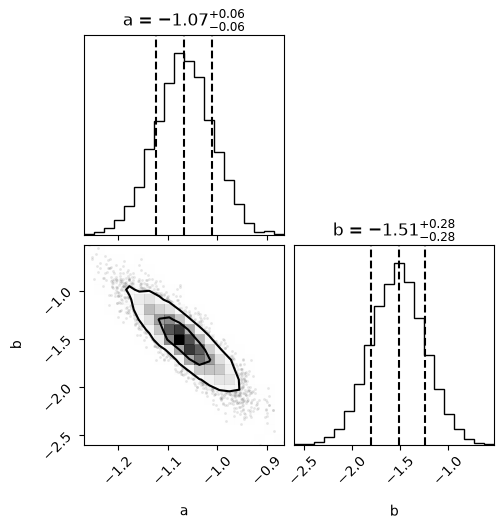

In [83]:
def get_observation(ds_id):
    d = df[df['dataset'] == ds_id]
    y = d['y'].to_numpy()
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    return torch.tensor(np.concatenate([y, x, sigma]), dtype=torch.float32)

#List of a, b found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["a", "b"]
fig = cp.corner(flat_samples[:, :2], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)

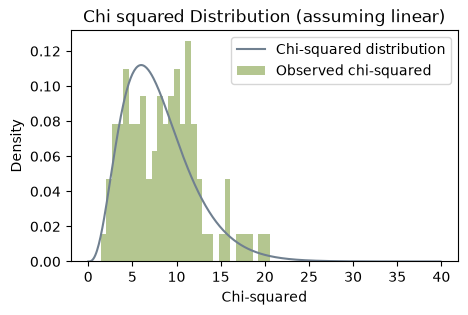

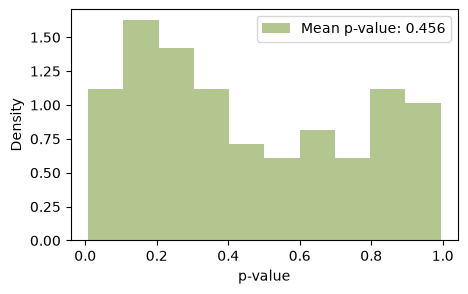

In [84]:
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean']

    y_sbi = a * d['x'] + b  
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_sbi) / sigma_obs) ** 2)
    chi2s.append(chi2)

chi2_dist = sp.stats.chi2(df=len(y_obs)-2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.legend()
plt.title('Chi squared Distribution (assuming linear)')
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

/Library/Frameworks/Python.framework/Versions/3.11/lib/python3.11/site-packages/sbi/inference/trainers/npe/npe_base.py:211: UserWarning: Data has extreme outliers in dimension(s) [0, 1, 2] (beyond 10.0x IQR from quartiles). This may cause precision loss during z-scoring, where distinct values become indistinguishable. Consider removing outliers from your data or setting `z_score_x='none'` (though this may affect training).
  warn_if_invalid_for_zscoring(x)


 Neural network successfully converged after 128 epochs. dataset    a_mean    a_std    b_mean    b_std    c_mean    c_std
       0  0.009430 0.040985 -1.156462 0.377616 -1.314150 0.658008
       1 -0.067037 0.062390  1.982870 0.650593  0.984012 1.228867
       2  0.027591 0.056651  1.757304 0.420108 -0.604799 0.439682
       3  0.022366 0.057200  1.727102 0.531906  1.261746 0.639119
       4  0.026001 0.060126 -1.233313 0.627792 -2.856655 1.195052
       5 -0.028304 0.128559  2.333454 1.115534  0.589013 1.368816
       6  0.004795 0.059896 -1.470741 0.569436 -3.990420 0.728023
       7 -0.024577 0.082617 -0.495236 0.870686 -3.620473 1.349546
       8  0.006234 0.062649  0.784201 0.748320  3.811281 1.981838
       9 -0.000717 0.047129 -1.828389 0.489740 -4.144391 1.042543
      10 -0.005057 0.046569 -0.351055 0.415029  1.066687 0.697442
      11 -0.102382 0.045402 -0.431474 0.340928 -3.661103 0.516555
      12  0.074437 0.059170  1.320197 0.641310  3.479371 1.403241
      13 -0.049058 0

  0%|          | 0/5000 [00:00<?, ?it/s]

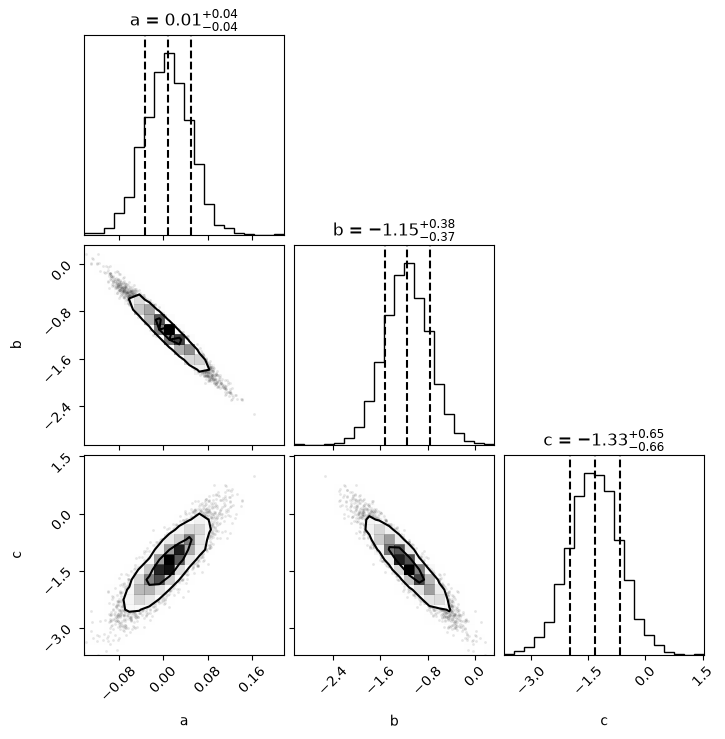

In [86]:
#Quadratic version
prior_4 = BoxUniform(low=torch.tensor([-6., -6., -7.]), 
                      high=torch.tensor([3., 6., 7.]))

prior_samples4 = prior_4.sample((10000,))

n_points = 10  

def quad_simulator(theta, x, sigma):
    coef_a, coef_b, coef_c = theta[0].item(), theta[1].item(), theta[2].item()
    sim_noise = np.random.normal(0, sigma, n_points)
    y_sim = coef_a * x**2 + coef_b * x + coef_c + sim_noise
    obs = np.concatenate([y_sim, x, sigma])
    return torch.tensor(obs, dtype=torch.float32)

n_simulations_per_dataset = 1000   
theta_train = []
x_train = []

for ds_id, d in datasets:
    x = d['x'].to_numpy()
    sigma = d['sigma'].to_numpy()
    thetas = prior_4.sample((n_simulations_per_dataset,))
    for theta in thetas:
        theta_train.append(theta)
        x_train.append(quad_simulator(theta, x, sigma))

theta_train = torch.stack(theta_train)
x_train = torch.stack(x_train)

inference = NPE(prior=prior_4)
inference.append_simulations(theta_train, x_train)
density_estimator = inference.train()
posterior = inference.build_posterior(density_estimator)

#List of a, b, c found for each dataset 
results_list = []

#Make a nice pretty table for a, b and corresponding sigmas found
for ds_id, d in list(datasets)[:]:
    obs = get_observation(ds_id)
    samples = posterior.sample((1000,), x=obs, show_progress_bars=False)
    posterior_mean = samples.mean(dim=0)
    posterior_std = samples.std(dim=0)
    
    results_list.append({
        'dataset': ds_id,
        'a_mean': posterior_mean[0].item(),
        'a_std': posterior_std[0].item(),
        'b_mean': posterior_mean[1].item(),
        'b_std': posterior_std[1].item(),
        'c_mean': posterior_mean[2].item(),
        'c_std': posterior_std[2].item(),
    })

results_df = pd.DataFrame(results_list)
print(results_df.to_string(index=False))

#Corner for the first dataset only
ds_id = 0
obs = get_observation(ds_id)
samples = posterior.sample((5000,), x=obs)

flat_samples = samples.numpy()

labels = ["a", "b", "c"]
fig = cp.corner(flat_samples[:, :3], labels=labels, truths=None, levels=[0.393, 0.865], quantiles=[0.16, 0.5, 0.84], title_quantiles=[0.16, 0.5, 0.84], show_titles=True, title_kwargs={"fontsize": 12})

posterior_mean = samples.mean(dim=0)


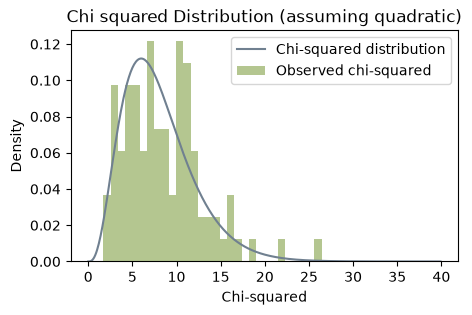

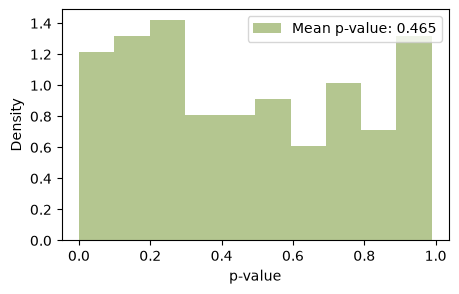

In [87]:
#Quadratic version
chi2s = []
for ds_id, d in list(datasets)[:]:
    a, b, c = results_list[ds_id]['a_mean'], results_list[ds_id]['b_mean'], results_list[ds_id]['c_mean']
    y_fit = a * d['x']**2 + b * d['x'] + c
    y_obs = d['y'].to_numpy()
    x_obs = d['x'].to_numpy()
    sigma_obs = d['sigma'].to_numpy()
    chi2 = np.sum(((y_obs - y_fit) / sigma_obs) ** 2)
    chi2s.append(chi2)

plt.figure(figsize=(5, 3))
plt.plot(np.arange(0, 40, 0.1), chi2_dist.pdf(np.arange(0, 40, 0.1)), color = 'slategray', label='Chi-squared distribution')
plt.hist(chi2s, bins=30, density=True, alpha=0.5, color = 'olivedrab', label='Observed chi-squared')
plt.xlabel('Chi-squared')
plt.ylabel('Density')
plt.title('Chi squared Distribution (assuming quadratic)')
plt.legend()
plt.show()

pvalues = 1 - chi2_dist.cdf(chi2s)
mean_p_4 = np.mean(pvalues)
plt.figure(figsize=(5, 3))
plt.hist(pvalues, bins=10, density=True, alpha=0.5, color = 'olivedrab',label=f'Mean p-value: {mean_p_4:.3f}')
plt.xlabel('p-value')
plt.ylabel('Density')
plt.legend()
plt.show()

In [59]:
def replicate_posterior(theta_samp, x, sigma):
    theta_np = theta_samp.detach().cpu().numpy()
    m = theta_np[:,0][:, None]
    b = theta_np[:,1][:, None]
    noise = np.random.normal(loc=0,scale=sigma[None,:], size = (len(theta_samp),len(x)))
    y_rep = m * x[None, :] +b +noise
    return y_rep

ds_id = 0

d = df[df['dataset'] == ds_id]

x_obs = d['x'].to_numpy()
y_obs = d['y'].to_numpy()
sigma_obs = d['sigma'].to_numpy()

#get observations from the posterior
obs = get_observation(ds_id)

posterior_samples = posterior.sample((5000,), x=obs,
    show_progress_bars=False)

#replicate data
y_rep = replicate_posterior(posterior_samples, x_obs, sigma_obs)


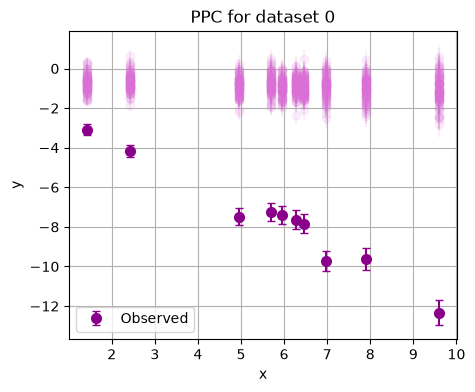

In [60]:
#plot some subset of replicate data points over 
#the observed data to see how well they match
fig, ax = plt.subplots(figsize=(5, 4))
for i in range(100):
    ax.errorbar(x_obs,
        y_rep[i],
        yerr=sigma_obs,
        fmt='o',
        color='orchid',
        alpha=0.1
    )

ax.errorbar(x_obs,
    y_obs,
    yerr=sigma_obs,
    fmt='o',
    color='darkmagenta',
    capsize=3,
    markersize=7,
    label='Observed'
)

ax.set_xlabel('x')
ax.set_ylabel('y')
ax.set_title(f'PPC for dataset {ds_id}')
ax.grid()
ax.legend()

plt.show()


$p_B$ for mean:1.0


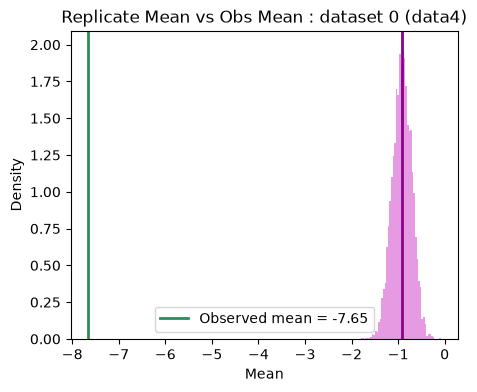

$\Delta$ mean = 6.74


In [61]:
#Use the mean as a test quantity 
T_obs_mean = np.mean(y_obs)
T_rep_mean = np.mean(y_rep, axis = 1)
p_B_mean = np.mean(T_rep_mean >= T_obs_mean)
T_rep_mean_mean = np.mean(T_rep_mean)

print(fr"$p_B$ for mean:{p_B_mean}")

fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_mean,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)

ax.axvline(T_rep_mean_mean,
    color='darkmagenta',
    linewidth=2,
)
ax.axvline(T_obs_mean,
    color='seagreen',
    linewidth=2,
    label=f'Observed mean = {T_obs_mean:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Mean vs Obs Mean : dataset {ds_id} (data4)')
ax.legend()

plt.show()

print(fr'$\Delta$ mean = {T_rep_mean_mean-T_obs_mean:.2f}')


p_B for standard deviation: 0.0


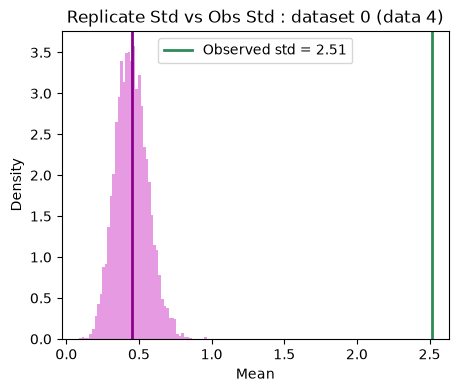

In [62]:
#do the same for std
T_obs_std = np.std(y_obs)
T_rep_std = np.std(y_rep, axis=1)
T_rep_std_mean = np.mean(T_rep_std)

p_B_std = np.mean(T_rep_std >= T_obs_std)

print("p_B for standard deviation:", p_B_std)
fig, ax = plt.subplots(figsize=(5, 4))

ax.hist(T_rep_std,
    bins=50,
    density=True,
    color='orchid',
    alpha=0.7
)
ax.axvline(T_rep_std_mean,
    color='darkmagenta',
    linewidth=2,
)

ax.axvline(T_obs_std,
    color='seagreen',
    linewidth=2,
    label=f'Observed std = {T_obs_std:.2f}'
)

ax.set_xlabel('Mean')
ax.set_ylabel('Density')
ax.set_title(f'Replicate Std vs Obs Std : dataset {ds_id} (data 4)')
ax.legend()

plt.show()


In [88]:
#Comparing all four p-values
print(f"Mean p-values for datasets 1-4 assuming linear model: 0.485, 0.455, 0.456, 0.456")
print(f'end=> Mean p-values for datasets 1-4 assuming quadratic model: {mean_p_1:.3f}, {mean_p_2:.3f}, {mean_p_3:.3f}, {mean_p_4:.3f}')
delta_p_1 = mean_p_1 - 0.485
delta_p_2 = mean_p_2 - 0.455
delta_p_3 = mean_p_3 - 0.456
delta_p_4 = mean_p_4 - 0.456
print(f'When changing from linear to quadratic model, p-values change by: {delta_p_1:.3f}, {delta_p_2:.3f}, {delta_p_3:.3f}, {delta_p_4:.3f}')

Mean p-values for datasets 1-4 assuming linear model: 0.485, 0.455, 0.456, 0.456
end=> Mean p-values for datasets 1-4 assuming quadratic model: 0.400, 0.467, 0.456, 0.465
When changing from linear to quadratic model, p-values change by: -0.085, 0.012, -0.000, 0.009
